# Task A – Main Results Evaluation
Loads all 25 saved models (5 datasets × 5 models), evaluates on the held-out **test set**, and produces:
- `results/main_results_table.csv` – the core comparison table
- Bar charts comparing models across datasets

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_squared_error, accuracy_score,
    roc_auc_score, log_loss
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT      = os.path.dirname(os.path.abspath(""))   # project root
DATA_DIR  = os.path.join(ROOT, "data")
MODEL_DIR = os.path.join(ROOT, "saved_models")
RES_DIR   = os.path.join(ROOT, "results")
os.makedirs(RES_DIR, exist_ok=True)

# Add src/ to path so we can reuse helpers if needed
sys.path.insert(0, os.path.join(ROOT, "src"))

print("Root:", ROOT)
print("Datasets available:", os.listdir(DATA_DIR))

Root: /home/wuxinzhe76/COMP9417-PR
Datasets available: ['bank_marketing', 'online_news', 'dry_bean', 'superconductivity', 'ai4i_maintenance']


In [4]:
# ── Dataset registry ──────────────────────────────────────────────────────────
DATASET_CONFIG = {
    "dry_bean":          {"task": "multiclass"},
    "ai4i_maintenance":  {"task": "binary"},
    "bank_marketing":    {"task": "binary"},
    "online_news":       {"task": "regression"},
    "superconductivity": {"task": "regression"},
}

MODEL_NAMES = ["xRFM", "XGBoost", "RF", "MLP", "TabNet"]

# ── Helper: load test split ────────────────────────────────────────────────────
def load_test_split(dataset_name):
    base = os.path.join(DATA_DIR, dataset_name, "test")
    X = pd.read_csv(os.path.join(base, "X.csv"))
    y = pd.read_csv(os.path.join(base, "y.csv")).iloc[:, 0]
    return X, y

def load_val_split(dataset_name):
    base = os.path.join(DATA_DIR, dataset_name, "val")
    X = pd.read_csv(os.path.join(base, "X.csv"))
    y = pd.read_csv(os.path.join(base, "y.csv")).iloc[:, 0]
    return X, y

# ── Helper: apply saved preprocessor (NO re-fit) ─────────────────────────────
def transform(meta, X_raw):
    scaler, ohe = meta["scaler"], meta["ohe"]
    num_cols, cat_cols = meta["num_cols"], meta["cat_cols"]
    parts = []
    if num_cols:
        parts.append(scaler.transform(X_raw[num_cols]))
    if cat_cols:
        parts.append(ohe.transform(X_raw[cat_cols]))
    return np.hstack(parts).astype(np.float32) if parts else np.empty((len(X_raw), 0), np.float32)

In [5]:
# ── Helper: load a saved model ────────────────────────────────────────────────
def load_model(dataset_name, model_key):
    """
    model_key: 'xrfm' | 'xgb' | 'rf' | 'mlp' | 'tabnet'
    Returns the loaded model object, or None if not found.
    """
    mdir = os.path.join(MODEL_DIR, dataset_name)

    if model_key == "tabnet":
        from pytorch_tabnet.tab_model import TabNetClassifier, TabNetRegressor
        task = DATASET_CONFIG[dataset_name]["task"]
        zip_path = os.path.join(mdir, "tabnet", "model.zip")
        if not os.path.exists(zip_path):
            return None
        cls = TabNetRegressor if task == "regression" else TabNetClassifier
        model = cls()
        model.load_model(zip_path)
        return model

    pkl = os.path.join(mdir, f"{model_key}.pkl")
    if not os.path.exists(pkl):
        return None
    return joblib.load(pkl)

# ── Helper: evaluate one model on test set ────────────────────────────────────
def evaluate(model, model_key, X_test_np, y_test_np, task):
    """
    Returns dict: rmse, accuracy, auc, infer_time_us
    Metrics not applicable for the task are set to NaN.
    """
    n = len(X_test_np)
    result = {"rmse": np.nan, "accuracy": np.nan, "auc": np.nan}

    # ── Prediction + inference time ───────────────────────────────────────────
    t0 = time.perf_counter()

    if model_key == "xrfm":
        raw_preds = model.predict(X_test_np)   # always returns float array
    elif model_key == "tabnet":
        if task == "regression":
            raw_preds = model.predict(X_test_np).ravel()
        else:
            raw_preds = model.predict(X_test_np).ravel()
    else:
        raw_preds = model.predict(X_test_np)

    infer_time_us = (time.perf_counter() - t0) / n * 1e6  # microseconds per sample

    # ── Metrics ───────────────────────────────────────────────────────────────
    if task == "regression":
        result["rmse"] = float(np.sqrt(mean_squared_error(y_test_np, raw_preds)))

    else:  # binary or multiclass
        if model_key == "xrfm":
            # xRFM was trained with MSE on integer labels → raw output is float
            if task == "binary":
                y_pred_cls = (raw_preds >= 0.5).astype(int)
                result["accuracy"] = float(accuracy_score(y_test_np, y_pred_cls))
                result["auc"]      = float(roc_auc_score(y_test_np, raw_preds))
            else:  # multiclass: round to nearest class
                y_pred_cls = np.clip(np.round(raw_preds).astype(int), 0,
                                     int(y_test_np.max()))
                result["accuracy"] = float(accuracy_score(y_test_np, y_pred_cls))
                # AUC not available for xRFM multiclass (no probability output)
                result["auc"] = np.nan

        elif model_key == "tabnet":
            result["accuracy"] = float(accuracy_score(y_test_np, raw_preds))
            # Get probabilities for AUC
            t0 = time.perf_counter()
            proba = model.predict_proba(X_test_np)
            if task == "binary":
                result["auc"] = float(roc_auc_score(y_test_np, proba[:, 1]))
            else:
                result["auc"] = float(roc_auc_score(
                    y_test_np, proba, multi_class="ovr", average="macro"))

        else:  # sklearn / XGBoost
            result["accuracy"] = float(accuracy_score(y_test_np, raw_preds))
            proba = model.predict_proba(X_test_np)
            if task == "binary":
                result["auc"] = float(roc_auc_score(y_test_np, proba[:, 1]))
            else:
                result["auc"] = float(roc_auc_score(
                    y_test_np, proba, multi_class="ovr", average="macro"))

    result["infer_time_us"] = round(infer_time_us, 4)
    return result

In [6]:
# ── Main evaluation loop ──────────────────────────────────────────────────────
MODEL_KEYS = {"xRFM": "xrfm", "XGBoost": "xgb", "RF": "rf",
              "MLP": "mlp", "TabNet": "tabnet"}

records = []

for dataset_name, cfg in DATASET_CONFIG.items():
    task = cfg["task"]
    print(f"\n{'='*55}")
    print(f"  {dataset_name.upper()}  ({task})")
    print('='*55)

    # Load preprocessor and test data
    meta     = joblib.load(os.path.join(MODEL_DIR, dataset_name, "preprocessor.pkl"))
    X_test_raw, y_test = load_test_split(dataset_name)
    X_test_np = transform(meta, X_test_raw)

    # Label encoding for multiclass
    le_path = os.path.join(MODEL_DIR, dataset_name, "label_encoder.pkl")
    if task == "multiclass" and os.path.exists(le_path):
        le = joblib.load(le_path)
        y_test_np = le.transform(y_test).astype(int)
    elif task == "regression":
        y_test_np = np.asarray(y_test, dtype=np.float64)
    else:
        y_test_np = np.asarray(y_test, dtype=int)

    for model_name, model_key in MODEL_KEYS.items():
        model = load_model(dataset_name, model_key)
        if model is None:
            print(f"  [{model_name}]  model file not found – skipping")
            continue

        try:
            metrics = evaluate(model, model_key, X_test_np, y_test_np, task)
            rec = {
                "dataset":        dataset_name,
                "task":           task,
                "model":          model_name,
                "RMSE":           round(metrics["rmse"], 4)     if not np.isnan(metrics["rmse"])     else "—",
                "Accuracy":       round(metrics["accuracy"], 4) if not np.isnan(metrics["accuracy"]) else "—",
                "AUC-ROC":        round(metrics["auc"], 4)      if not np.isnan(metrics["auc"])      else "—",
                "Infer_us/sample": metrics["infer_time_us"],
            }
            records.append(rec)
            print(f"  [{model_name:8s}]  "
                  f"RMSE={rec['RMSE']:<10}  Acc={rec['Accuracy']:<8}  "
                  f"AUC={rec['AUC-ROC']:<8}  "
                  f"Infer={rec['Infer_us/sample']:.3f}µs")
        except Exception as e:
            print(f"  [{model_name}]  ERROR – {e}")

print("\n✓ Evaluation complete.")


  DRY_BEAN  (multiclass)
Using soft routing for tree prediction
  [xRFM    ]  RMSE=—           Acc=0.8358    AUC=—         Infer=23.717µs
  [XGBoost ]  RMSE=—           Acc=0.9254    AUC=0.9951    Infer=13.726µs
  [RF      ]  RMSE=—           Acc=0.9214    AUC=0.9928    Infer=56.825µs
  [MLP     ]  RMSE=—           Acc=0.9185    AUC=0.9949    Infer=1.204µs
  [TabNet  ]  RMSE=—           Acc=0.9144    AUC=0.9941    Infer=22.380µs

  AI4I_MAINTENANCE  (binary)
Using soft routing for tree prediction
  [xRFM    ]  RMSE=—           Acc=0.978     AUC=0.9276    Infer=5.925µs
  [XGBoost ]  RMSE=—           Acc=0.9855    AUC=0.9692    Infer=2.622µs
  [RF      ]  RMSE=—           Acc=0.9795    AUC=0.9651    Infer=66.212µs
  [MLP     ]  RMSE=—           Acc=0.9755    AUC=0.9604    Infer=1.074µs
  [TabNet  ]  RMSE=—           Acc=0.9745    AUC=0.9431    Infer=18.466µs

  BANK_MARKETING  (binary)
Using soft routing for tree prediction
  [xRFM    ]  RMSE=—           Acc=0.9067    AUC=0.924     Infe

In [7]:
# ── Build results table and save to CSV ──────────────────────────────────────
results_df = pd.DataFrame(records)

out_path = os.path.join(RES_DIR, "main_results_table.csv")
results_df.to_csv(out_path, index=False)
print(f"Saved → {out_path}\n")

# Pretty-print the full table
with pd.option_context("display.max_rows", 50, "display.max_columns", 20,
                        "display.width", 120):
    display(results_df)

Saved → /home/wuxinzhe76/COMP9417-PR/results/main_results_table.csv



,dataset,task,model,RMSE,Accuracy,AUC-ROC,Infer_us/sample
0,dry_bean,multiclass,xRFM,—,0.8358,—,23.7169
1,dry_bean,multiclass,XGBoost,—,0.9254,0.9951,13.7262
2,dry_bean,multiclass,RF,—,0.9214,0.9928,56.8249
3,dry_bean,multiclass,MLP,—,0.9185,0.9949,1.2036
4,dry_bean,multiclass,TabNet,—,0.9144,0.9941,22.3803
5,ai4i_maintenance,binary,xRFM,—,0.978,0.9276,5.9249
6,ai4i_maintenance,binary,XGBoost,—,0.9855,0.9692,2.6224
7,ai4i_maintenance,binary,RF,—,0.9795,0.9651,66.2118
8,ai4i_maintenance,binary,MLP,—,0.9755,0.9604,1.0736
9,ai4i_maintenance,binary,TabNet,—,0.9745,0.9431,18.4659


## Visualisation: Model Comparison per Dataset

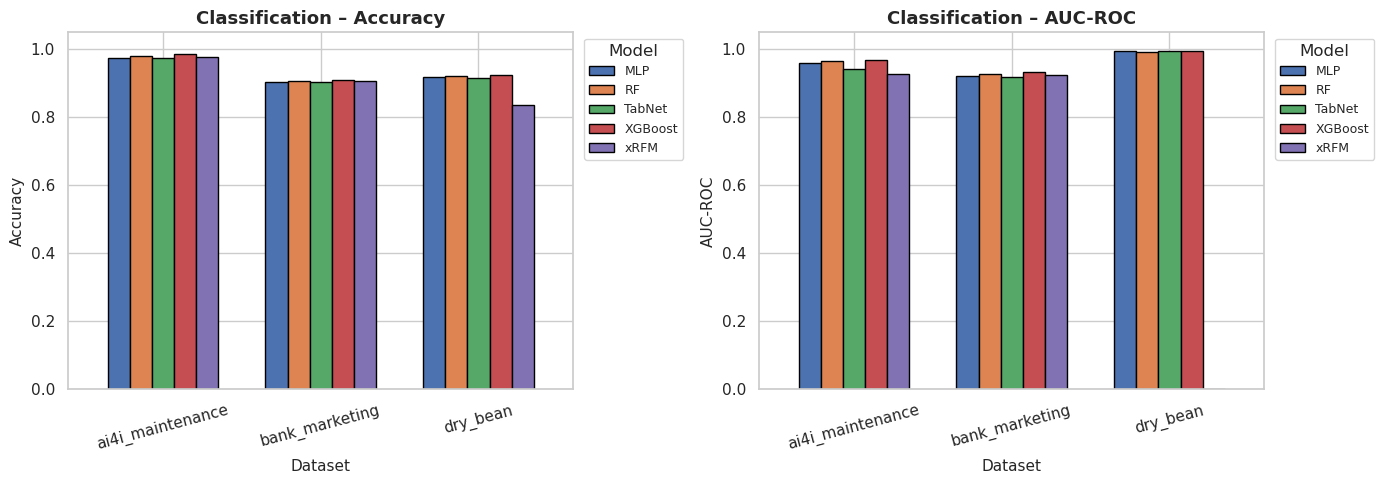

Saved → results/classification_accuracy_auc.png


In [8]:
# ── Plot 1: Accuracy / AUC for classification datasets ───────────────────────
clf_df = results_df[results_df["task"].isin(["binary", "multiclass"])].copy()
clf_df["Accuracy"] = pd.to_numeric(clf_df["Accuracy"], errors="coerce")
clf_df["AUC-ROC"]  = pd.to_numeric(clf_df["AUC-ROC"],  errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ["Accuracy", "AUC-ROC"]):
    pivot = clf_df.pivot(index="dataset", columns="model", values=metric)
    pivot.plot(kind="bar", ax=ax, edgecolor="black", width=0.7)
    ax.set_title(f"Classification – {metric}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Dataset", fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "classification_accuracy_auc.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/classification_accuracy_auc.png")

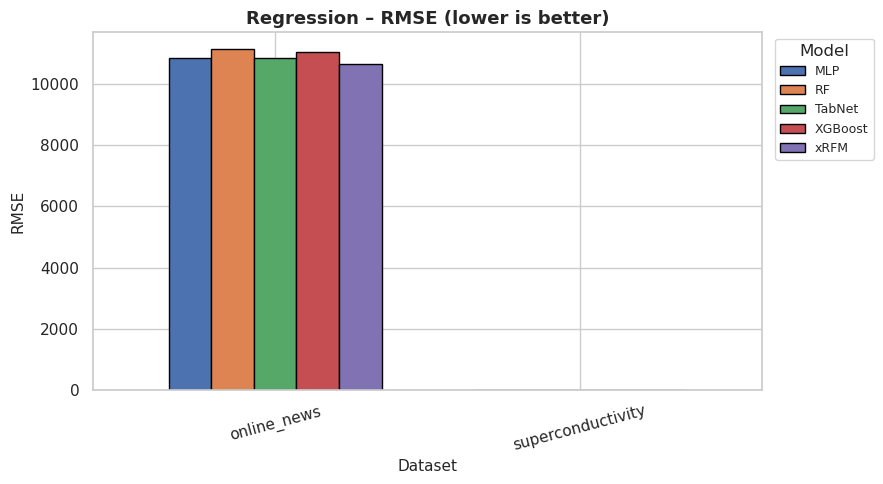

Saved → results/regression_rmse.png


In [9]:
# ── Plot 2: RMSE for regression datasets ─────────────────────────────────────
reg_df = results_df[results_df["task"] == "regression"].copy()
reg_df["RMSE"] = pd.to_numeric(reg_df["RMSE"], errors="coerce")

pivot_rmse = reg_df.pivot(index="dataset", columns="model", values="RMSE")

fig, ax = plt.subplots(figsize=(9, 5))
pivot_rmse.plot(kind="bar", ax=ax, edgecolor="black", width=0.7)
ax.set_title("Regression – RMSE (lower is better)", fontsize=13, fontweight="bold")
ax.set_xlabel("Dataset", fontsize=11)
ax.set_ylabel("RMSE", fontsize=11)
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "regression_rmse.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/regression_rmse.png")

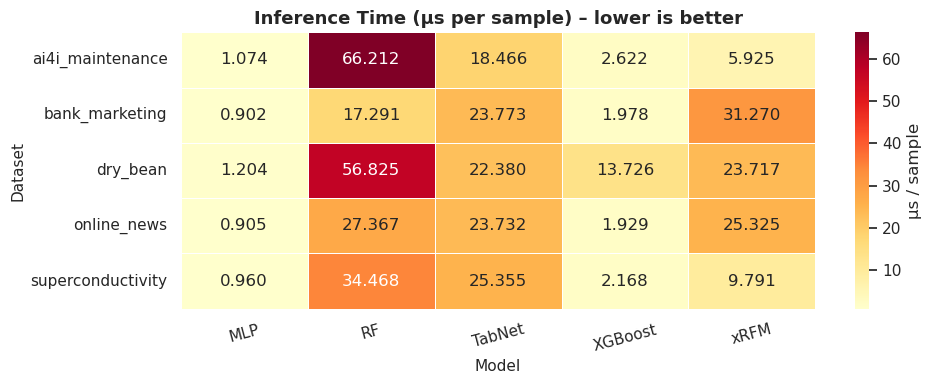

Saved → results/inference_time_heatmap.png


In [10]:
# ── Plot 3: Inference time heatmap (all datasets × models) ───────────────────
infer_df = results_df.copy()
infer_df["Infer_us/sample"] = pd.to_numeric(infer_df["Infer_us/sample"], errors="coerce")
pivot_infer = infer_df.pivot(index="dataset", columns="model", values="Infer_us/sample")

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot_infer,
    annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "µs / sample"}
)
ax.set_title("Inference Time (µs per sample) – lower is better",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Dataset", fontsize=11)
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "inference_time_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/inference_time_heatmap.png")

In [11]:
# ── Summary: xRFM rank across datasets ───────────────────────────────────────
print("=" * 60)
print("xRFM PERFORMANCE SUMMARY")
print("=" * 60)

for _, row in results_df[results_df["model"] == "xRFM"].iterrows():
    task = row["task"]
    if task == "regression":
        print(f"  {row['dataset']:25s}  RMSE={row['RMSE']}")
    else:
        print(f"  {row['dataset']:25s}  Acc={row['Accuracy']}  AUC={row['AUC-ROC']}")

xRFM PERFORMANCE SUMMARY
  dry_bean                   Acc=0.8358  AUC=—
  ai4i_maintenance           Acc=0.978  AUC=0.9276
  bank_marketing             Acc=0.9067  AUC=0.924
  online_news                RMSE=10662.5738
  superconductivity          RMSE=9.8063
